## Calculating Lift and drag

Currently we have 3 possibilities to compute lift $L$ and drag $D$ on the cylinder as a function of time $t$, each suited for different geometry representation. The purpose of this notebook is to use these three methods to compute the lift and drag in both a meshed and immersed setting to and compare the results.



### Method 1: A surface integral.

If one has a fully meshed geometry, the most natural way to compute lift and drag is by computing a surface integral of the pressure and viscous components, and projecting on the $x$ and $y$ directions. Fortunately, this functionality exists as a `simulation_component` known as `force_torque`. Hence, $L(t)$ and $D(t)$ can be read directly from the log file.

In [1]:
def read_force_torque(path_name):
    # note!
    # I bet this isn't the best for long logfiles!
    t_list = []
    fx_tot_list = []
    fx_visc_list = []
    fx_p_list = []
    fy_tot_list = []
    fy_visc_list = []
    fy_p_list = []
    
    with open(path_name) as file:
        for line in file:
            s = line.rstrip()
            index = s.find("forcex")
            if index >= 1: 
                numbers = np.array(line.rstrip().split())
                t_list.append(numbers[1].astype(float))
                fx_tot_list.append(numbers[2].astype(float))
                fx_p_list.append(numbers[3].astype(float))
                fx_visc_list.append(float(numbers[4][:-1]))
            index = s.find("forcey")
            if index >= 1:
                numbers = np.array(line.rstrip().split())
                fy_tot_list.append(numbers[2].astype(float))
                fy_p_list.append(numbers[3].astype(float))
                fy_visc_list.append(float(numbers[4][:-1]))
            
    t = np.array(t_list)
    fx_tot = np.array(fx_tot_list)
    fx_p = np.array(fx_p_list)
    fx_visc = np.array(fx_visc_list)
    fy_tot = np.array(fy_tot_list)
    fy_p = np.array(fy_p_list)
    fy_visc = np.array(fy_visc_list)

    return t, fx_tot, fx_p, fx_visc, fy_tot, fy_p, fy_visc

### Method 2: Surface integral via probes

If this was a surface, we would be integrating the traction $\mathbf{\sigma} \mathbf{n}$ on the boundary, ie,

$\mathbf{F} = \int_{\partial \Omega} \mathbf{\sigma} \mathbf{n} \, dS,$

where $\mathbf{n}$ is the normal vector and $\mathbf{\sigma}$ is the stress tensor, which, for a Newtonian fluid, takes the form $\mathbf{\sigma} = \mu \left( \nabla \mathbf{u} + (\nabla \mathbf{u})^T\right) - \mathbf{I}p$.

Given the interface is not necesarily known for the IBM, we can take concentric rings and compute the "surface integral"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def surface_integral_from_probes(input_filename, Re):
    # Read the first line to get the number of points
    with open(input_filename, 'r') as file:
        first_line = file.readline().strip()
        n = int(first_line.split(',')[0])  # Extract the first value as the number of points
    
    # Read coordinates
    coordinates = pd.read_csv(input_filename, skiprows=1, nrows=n, header=None)
    x_coords = coordinates.values[:, 0]  # All x-coordinates (first column)
    y_coords = coordinates.values[:, 1]  # All y-coordinates (second column)
    
    # Read the data from row n+1 onwards
    data = pd.read_csv(input_filename, skiprows=n + 1, header=None)
    
    
    
    # Extract time and variable columns
    time = data[0]  # Column A is time
    u = data[1] # Column B is u
    v = data[2] # Column C is v
    w = data[3] # Column D is w
    p = data[4] # Column E is p
    # print ("data.shape[1]=" , data.shape[1])
    if data.shape[1] > 8:
        dudx = data[5]     # Column F is dudx
        dudy = data[6]     # Column G is dudy
        dvdx = data[7]     # Column H is dvdx
        dvdy = data[8]     # Column I is dvdy
        derivative_available = True
    print("Loading data from file (",os.path.basename(input_filename),") successfully done. n= ", n, " points/probs detected.")
    print(derivative_available)
    radius = np.sqrt(x_coords[0]**2 + y_coords[0]**2)  # Radius of the circle
    # Calculate theta for each probe based on x and y coordinates
    theta = np.arctan2(y_coords, x_coords)  # Angle in radians for each probe
    
    
    
    num_timesteps = int(len(time) / n)
    time_reshaped = np.zeros((n, num_timesteps))
    p_reshaped = np.zeros((n, num_timesteps))
    u_reshaped = np.zeros((n, num_timesteps))
    v_reshaped = np.zeros((n, num_timesteps))
    
    dudx_reshaped = np.zeros((n, num_timesteps))
    dudy_reshaped = np.zeros((n, num_timesteps))
    dvdx_reshaped = np.zeros((n, num_timesteps))
    dvdy_reshaped = np.zeros((n, num_timesteps))
    
    # Loop to manually fill the reshaped arrays
    for i in range(0, n-1, 1):
        # For each probe i, fill the corresponding row in each reshaped array
        time_reshaped[i,:] = time.values[i::n]
        p_reshaped[i,:] = p.values[i::n]
        u_reshaped[i,:]= u.values[i::n]
        v_reshaped[i,:] = v.values[i::n]
    
        dudx_reshaped[i,:] = dudx.values[i::n]
        dudy_reshaped[i,:] = dudy.values[i::n]
        dvdx_reshaped[i,:] = dvdx.values[i::n]
        dvdy_reshaped[i,:] = dvdy.values[i::n]

    # Initialize arrays to store drag, lift, and shear components
    drag = np.zeros(num_timesteps)
    lift = np.zeros(num_timesteps)
    shear_drag = np.zeros(num_timesteps)
    shear_lift = np.zeros(num_timesteps)
    
    
    # Calculate the arc length per segment

    dS = (2 * np.pi * radius) / n
  
    
    # Loop over each time step to calculate drag and lift
    for t in range(num_timesteps):
        # Get pressure and angle for each probe at this time step
        p_t = p_reshaped[:, t]
        
        
        
        # Get shear components (du/dn and dv/dn) for each probe at this time step
        #du_dn = np.cos(theta) * dudx_reshaped[:, t] + np.sin(theta) * dudy_reshaped[:, t]
        #dv_dn = np.cos(theta) * dvdx_reshaped[:, t] + np.sin(theta) * dvdy_reshaped[:, t]
        
        # Compute the shear drag and lift components (using du/dn and dv/dn)
        #shear_drag_components = du_dn * np.cos(theta)  # Shear contribution to drag
        #shear_lift_components = dv_dn * np.sin(theta)  # Shear contribution to lift
        
        shear_drag_components = ( dudx_reshaped[:, t] * 2                    * np.cos(theta) + \
                                 (dvdx_reshaped[:, t] + dudy_reshaped[:, t]) * np.sin(theta))/Re  # Shear contribution to drag
        shear_lift_components = ((dvdx_reshaped[:, t] + dudy_reshaped[:, t]) * np.cos(theta) + \
                                  dvdy_reshaped[:, t] * 2                    * np.sin(theta))/Re  # Shear contribution to lift
        
        # Compute the drag and lift components from pressure
        drag_components = -p_t * np.cos(theta)
        lift_components = -p_t * np.sin(theta)
        
        # Integrate around the circle (sum and multiply by 2 * pi / n for full circle)
        drag[t] = np.sum(drag_components) * dS
        lift[t] = np.sum(lift_components) * dS
        shear_drag[t] = np.sum(shear_drag_components) * dS
        shear_lift[t] = np.sum(shear_lift_components) * dS
    
    # Total drag and lift (pressure + shear)(1/Re)(Re=200)
    total_drag = drag + shear_drag
    total_lift = lift + shear_lift
    time_values = time_reshaped[0,:] # Extract the time from the last probe's time array

    return time_values, total_drag, drag, shear_drag, total_lift, lift, shear_lift

### Method 3: Total force excerted by the Brinkman term

The Brinkman style immersed boundary method imposes the presence of the geometry by the inclusion of a forcing term $\mathbf{f} = \chi \mathbf{u}$ where $\chi \in [0, \bar{\chi}]$ is a scalar field taking the maximum value $\chi  = \bar{\chi}$ in the solid region (forcing the velocity $\mathbf{u} << 1$) and taking the value $\chi = 0$ in the fluid region, recovering the standard Navier-Stokes equations.

By integrating this term in the domain one can calculate the total force excerted without requiring explicit knowledge of the interface location, ie,

$L = \int_\Omega \chi v \, d\Omega$ 

and 

$D = \int_\Omega \chi u \, d\Omega$

This has also been calcuated in the subroutine `user_calc_quantities` in `cylinder.f90`.

In [3]:
def read_brinkman_force(path_name):
    t_list = []
    fx_list = []
    fy_list = []
    
    with open(path_name) as file:
        for line in file:
            s = line.rstrip()
            index = s.find("Lift")
            if index >= 1:
                numbers = np.array(line.rstrip().split())
                t_list.append(numbers[4].astype(float))
                fy_list.append(numbers[2].astype(float))
            index = s.find("Drag")
            if index >= 1:
                numbers = np.array(line.rstrip().split())
                fx_list.append(numbers[2].astype(float))
    
    t = np.array(t_list)
    fx = np.array(fx_list)
    fy = np.array(fy_list)
    return t, fx, fy

## A test case

**Note:** We should probably be plotting $C_L$ and $C_D$ when it comes time to looking at different Reynolds numbers!

In [33]:
def calc_lift_and_drag(root_name,case_name,method,Re):
    # somehow search for all the rings! If i was better at python I would use the os somehow to find everything starting with 'circ'
    # but I'm not.. so I'm listing them manually.
    circ_list = ['048', '050', '0501', '0502', '0505', '051', '052', '055']
    # First is lift and drag
    if method == 'meshed':
        # here we just need the logfile
        path_name = root_name + case_name + '/cylinder.log' 
        t, fx_tot, fx_p, fx_visc, fy_tot, fy_p, fy_visc = read_force_torque(path_name)
        force_measure = {}
        force_measure["t"] = t
        force_measure["fx_tot"] = fx_tot
        force_measure["fx_p"] = fx_p
        force_measure["fx_visc"] = fx_visc
        force_measure["fy_tot"] = fy_tot
        force_measure["fy_p"] = fy_p
        force_measure["fy_visc"] = fy_visc
        force_measure["type"] = "meshed"
        all_forces = [force_measure]
        # We could in principal use method 2, but it's not required I guess.
    elif method == 'brinkman':
        # Now we have concentric rings
        all_forces = []
        for i in range(len(circ_list)):
            path_name = root_name + case_name + '/circ_' + circ_list[i] + '.csv'
            t, fx_tot, fx_p, fx_visc, fy_tot, fy_p, fy_visc = surface_integral_from_probes(path_name, Re)
            force_measure = {}
            force_measure["t"] = t
            force_measure["fx_tot"] = fx_tot
            force_measure["fx_p"] = fx_p
            force_measure["fx_visc"] = fx_visc
            force_measure["fy_tot"] = fy_tot
            force_measure["fy_p"] = fy_p
            force_measure["fy_visc"] = fy_visc
            force_measure["type"] = 'circ_' + circ_list[i]
            all_forces.append(force_measure)

        # we also have the 3rd measure
        path_name = root_name + case_name + "/cylinder.log"
        t, fx_tot, fy_tot = read_brinkman_force(path_name)
        # let's just fill the others with zeros to indicate this is the strange one:
        fx_p = np.zeros(len(t))
        fx_visc = np.zeros(len(t))
        fy_p = np.zeros(len(t))
        fy_visc = np.zeros(len(t))
        force_measure = {}
        force_measure["t"] = t
        force_measure["fx_tot"] = fx_tot
        force_measure["fx_p"] = fx_p
        force_measure["fx_visc"] = fx_visc
        force_measure["fy_tot"] = fy_tot
        force_measure["fy_p"] = fy_p
        force_measure["fy_visc"] = fy_visc
        force_measure["type"] = 'method3'
        all_forces.append(force_measure)
    elif method == 'idw':
        # I guess we do the same as brinkman without the last step
        # Now we have concentric rings
        all_forces = []
        for i in range(len(circ_list)):
            path_name = root_name + case_name + '/circ_' + circ_list[i] + '.csv'
            t, fx_tot, fx_p, fx_visc, fy_tot, fy_p, fy_visc = surface_integral_from_probes(path_name, Re)
            force_measure = {}
            force_measure["t"] = t
            force_measure["fx_tot"] = fx_tot
            force_measure["fx_p"] = fx_p
            force_measure["fx_visc"] = fx_visc
            force_measure["fy_tot"] = fy_tot
            force_measure["fy_p"] = fy_p
            force_measure["fy_visc"] = fy_visc
            force_measure["type"] = 'circ_' + circ_list[i]
            all_forces.append(force_measure)
    else:
        print('INCORRECT METHOD!')

    return all_forces

In [29]:
def plot_lift_drag(case_list, lift_axis, drag_axis):
    fig, ax = plt.subplots(2,1, figsize=(10, 5), dpi = 200)
    for j in range(len(case_list)):
        case = case_list[j]
        for i in range(len(case["forces"])):
            force_measure = case["forces"][i]
            # I can tell already we only only want 0.5
            # but this can be changed
            if force_measure["type"] == 'circ_050' or force_measure["type"] == 'meshed' or force_measure["type"] == 'method3':
                ax[0].plot(force_measure["t"], force_measure["fy_tot"],label=case["name"] + force_measure["type"])
                ax[1].plot(force_measure["t"], force_measure["fx_tot"], label=case["name"] + force_measure["type"])
    ax[0].set_ylabel("Lift")
    ax[1].set_ylabel("Drag")
    ax[1].set_xlabel("Time")
    ax[0].set_ylim(lift_axis)
    ax[1].set_ylim(drag_axis)
    ax[1].legend()
    plt.show()
    
            

        
    

In [34]:
# variable parameters



import sys
import os
import numpy as np
import matplotlib.pyplot as plt

results_path = "../../../results/brinkman_parameters/cases/"
meshed_path = "meshed_mesh_2_re_2000"
brinkman_path = "brinkman_mesh_2_re_200_chi_100_radius_0-03"

meshed = {}
IBM = {}
meshed["name"] = 'meshed'
IBM["name"] = 'IBM'

meshed["forces"] = calc_lift_and_drag(results_path,meshed_path,'meshed', 200)
IBM["forces"] = calc_lift_and_drag(results_path,brinkman_path,'brinkman', 200)

# make a list of cases
case_list = [meshed, IBM]

# plotting parameters
lift_axis = [-1, 1]
drag_axis = [0, 1.5]

plot_lift_drag(case_list, lift_axis, drag_axis)


Loading data from file ( circ_048.csv ) successfully done. n=  720  points/probs detected.
True
Loading data from file ( circ_050.csv ) successfully done. n=  720  points/probs detected.
True
Loading data from file ( circ_0501.csv ) successfully done. n=  720  points/probs detected.
True
Loading data from file ( circ_0502.csv ) successfully done. n=  720  points/probs detected.
True
Loading data from file ( circ_0505.csv ) successfully done. n=  720  points/probs detected.
True
Loading data from file ( circ_051.csv ) successfully done. n=  720  points/probs detected.
True
Loading data from file ( circ_052.csv ) successfully done. n=  720  points/probs detected.
True
Loading data from file ( circ_055.csv ) successfully done. n=  720  points/probs detected.
True


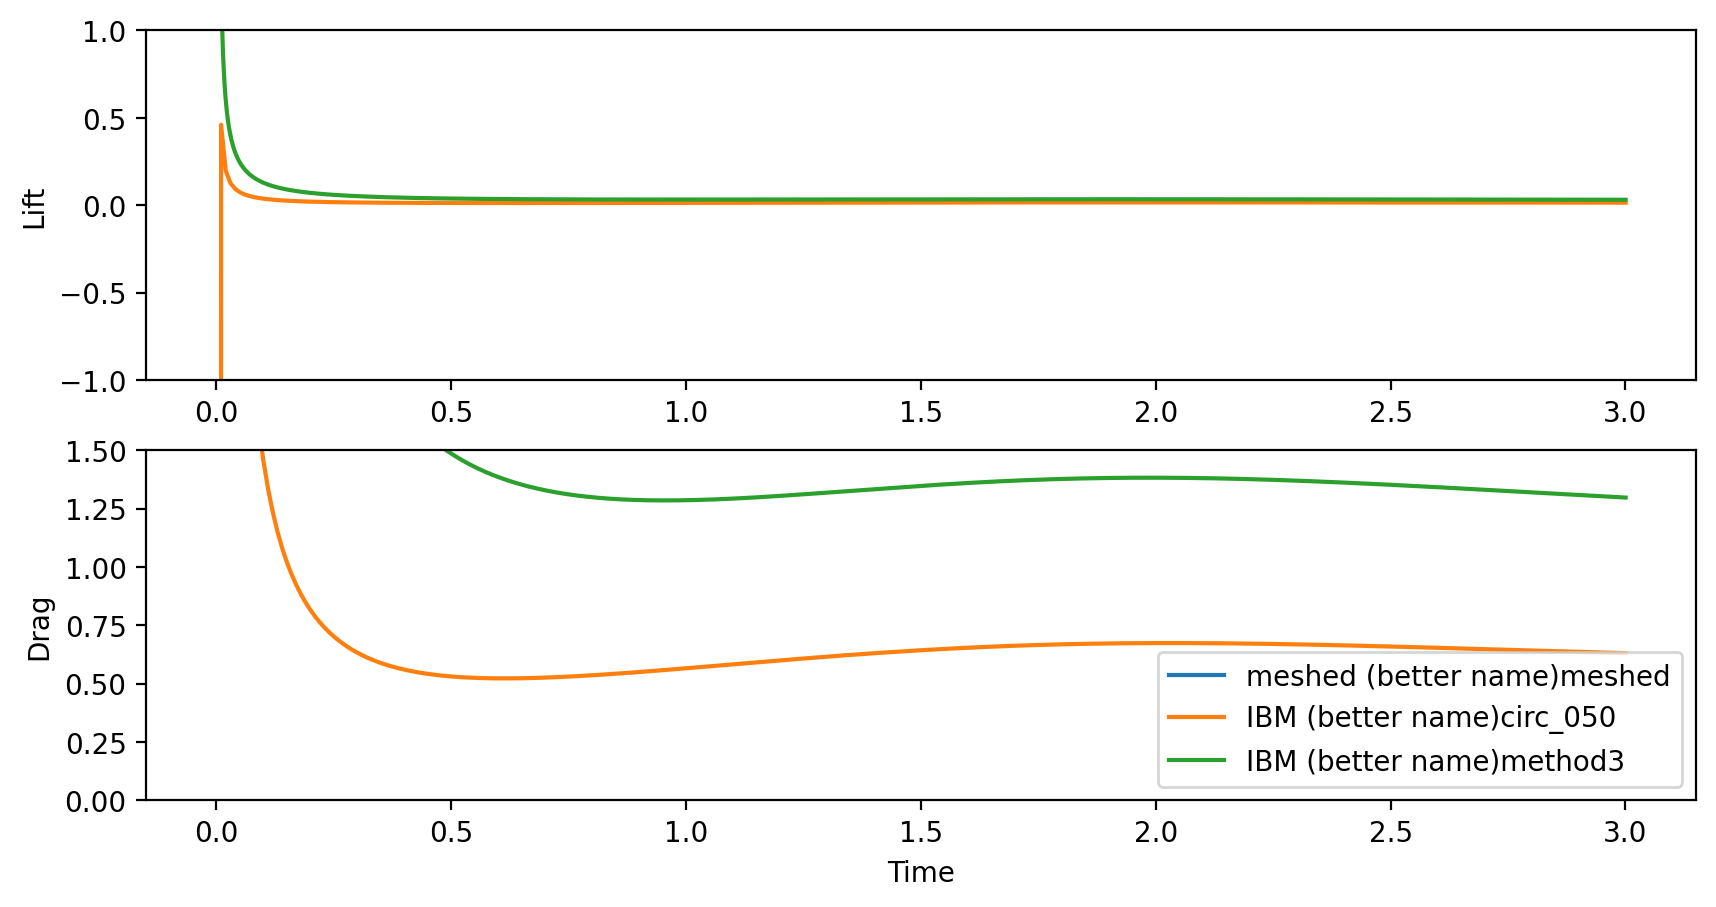

In [35]:
plot_lift_drag(case_list, lift_axis, drag_axis)

In [ ]:
# variable parameters
results_path = "../../../results/brinkman_parameters/cases/"
meshed_path = "meshed_mesh_4_re_200/"
brinkman_path = "brinkman_mesh_2_re_200_chi_100_radius_0-03/"





import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# A meshed cyclinder
path_name = results_path+meshed_path+"cylinder.log"
meshed_t, meshed_fx_tot, meshed_fx_p, meshed_fx_visc, meshed_fy_tot, meshed_fy_p, meshed_fy_visc \
= read_force_torque(path_name)

# An immersed cyclinder with probes
Re = 200
path_name = results_path+brinkman_path+"circ_051.csv"
IBM_t, IBM_fx_tot, IBM_fx_p, IBM_fx_visc, IBM_fy_tot, IBM_fy_p, IBM_fy_visc \
= surface_integral_from_probes(path_name, Re)

# A meshed cylinder with probes
path_name = results_path+meshed_path+"circ_050.csv" # I don't know why we call the 050 is actually 0.51 in the meshed case..
m_t, m_fx_tot, m_fx_p, m_fx_visc, m_fy_tot, m_fy_p, m_fy_visc \
= surface_integral_from_probes(path_name, Re)





# An immersed cylinder the other way
path_name = results_path+brinkman_path+"cylinder.log"
other_t, other_fx_tot, other_fy_tot = read_brinkman_force(path_name)


NameError: name 'meshed_t' is not defined

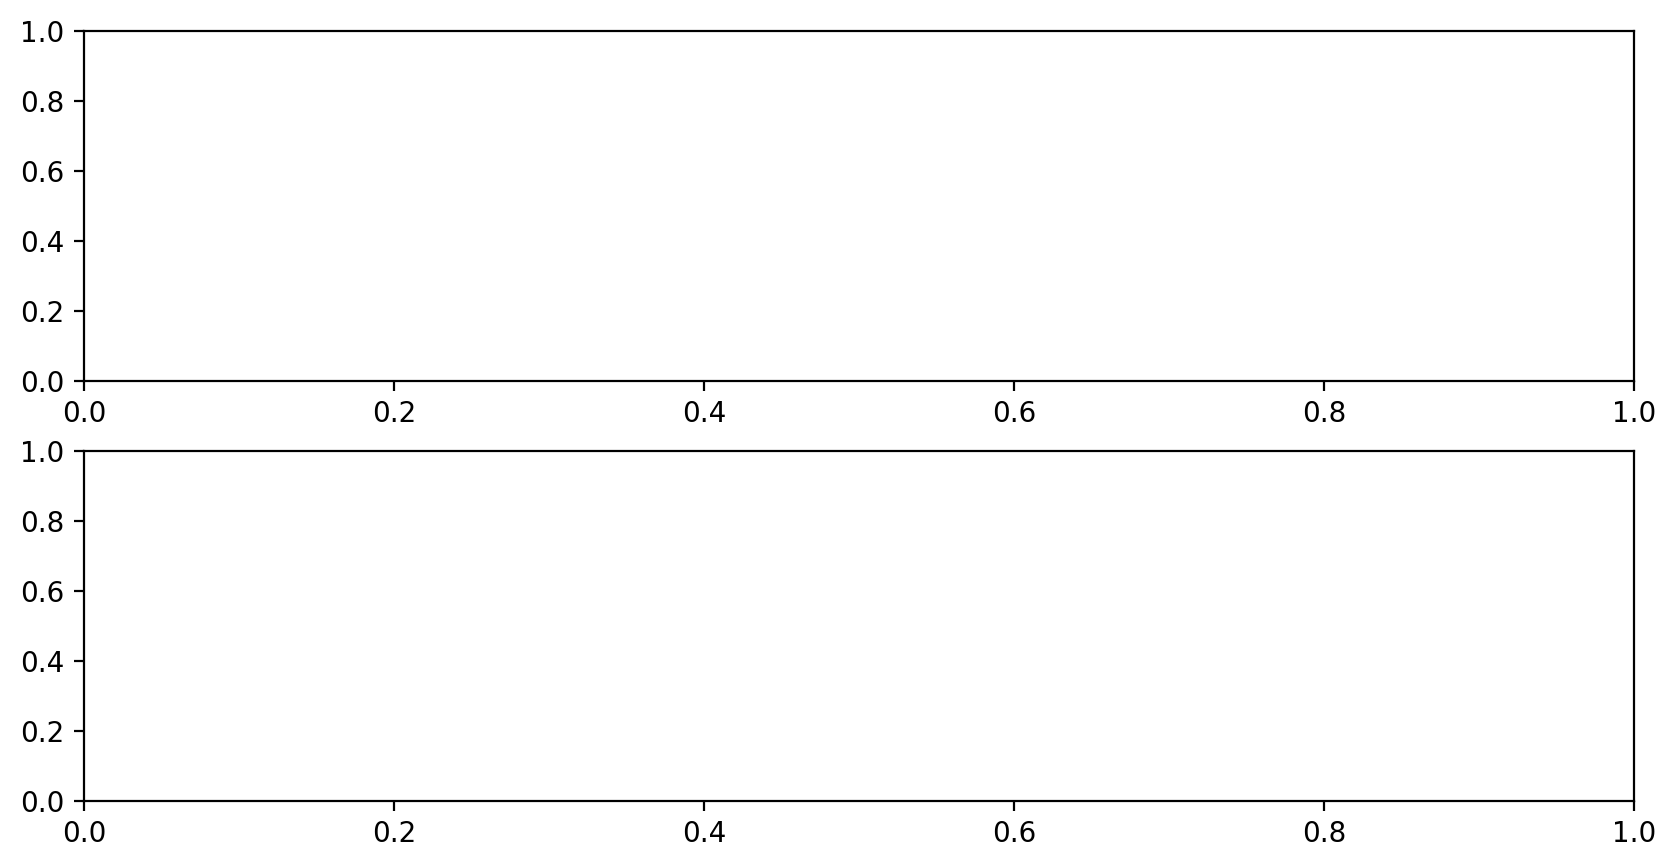

In [30]:
# plotting parameter
lift_axis = [-1, 1]
drag_axis = [0, 1.5]

fig, ax = plt.subplots(2,1, figsize=(10, 5), dpi = 200)
ax[0].plot(meshed_t, meshed_fy_tot)
ax[0].plot(IBM_t, IBM_fy_tot)
ax[0].plot(m_t, m_fy_tot)
ax[0].plot(other_t, other_fy_tot)
ax[0].set_ylim(lift_axis)
ax[0].set_ylabel("Lift")

ax[1].plot(meshed_t, meshed_fx_tot, label='Meshed')
ax[1].plot(IBM_t, IBM_fx_tot, label='IBM (probes at 0.51)')
ax[1].plot(m_t, m_fx_tot, label='Meshed (probes at 0.51)')
ax[1].plot(other_t, other_fx_tot, label='IBM ($\chi u$)')
ax[1].set_ylim(drag_axis)
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Drag")
ax[1].legend()
plt.show()

## Tabulate
We should have a general function for taking the mean and amplitude after some cutoff threshold..

In [ ]:
def mean_amp(t, x, t_start):
    inds = np.where(t > t_start)
    mean = np.mean(x[inds])
    # probs not the best metric for "amplitude"
    # VERY conservative, take the MAX separation and divide by two.
    amplitude = (np.max(x[inds]) - np.min(x[inds]))/2

    # I'm not good with python... if this was matlab I would 
    # - use `findpeaks`
    # - classify them on either side of the mean
    # - take the mean/standard deviation of the points
    # - calculate a mean/stdv on the amplitude
    return mean, amplitude

In [ ]:
t_start = 2.0
meshed_mean_L, meshed_amplitude_L = mean_amp(meshed_t, meshed_fy_tot, t_start)
meshed_mean_D, meshed_amplitude_D = mean_amp(meshed_t, meshed_fx_tot, t_start)
IBM_mean_L, IBM_amplitude_L = mean_amp(IBM_t, IBM_fy_tot, t_start)
IBM_mean_D, IBM_amplitude_D = mean_amp(IBM_t, IBM_fx_tot, t_start)
m_mean_L, m_amplitude_L = mean_amp(m_t, m_fy_tot, t_start)
m_mean_D, m_amplitude_D = mean_amp(m_t, m_fx_tot, t_start)
#other_mean_L, other_amplitude_L = mean_amp(other_t, other_fy_tot, t_start)
#other_mean_D, other_amplitude_D = mean_amp(other_t, other_fx_tot, t_start)

print('            Lift      Drag')
print('meshed (1) |'+ "{:05f}".format(meshed_mean_L) + '  ' + "{:05f}".format(meshed_mean_D))
print('IBM    (2) |'+ "{:05f}".format(IBM_mean_L) + '  ' + "{:05f}".format(IBM_mean_D))
print('meshed (2) |'+ "{:05f}".format(m_mean_L) + '  ' + "{:05f}".format(m_mean_D))
#print('IBM    (3) |'+ "{:05f}".format(other_mean_L) + '  ' + "{:05f}".format(other_mean_D))

In [37]:
bool(0)

False